In [12]:
# ------------------------------ imports ------------------------------------- #
import os                                                               # Python v3.10.13
import json                                                             # Python v3.10.13
import re                                                               # Python v3.10.13   
import ast                                                              # Python v3.10.13
from collections import Counter                                         # Python v3.10.13
from pathlib import Path                                                # Python v3.10.13
from multiprocessing import Pool, cpu_count                             # Python v3.10.13
import numpy as np                                                      # v1.26.4
import pandas as pd                                                     # v2.2.2
import matplotlib.pyplot as plt                                         # v3.8.4
import matplotlib as mpl                                                # v3.8.4           
from matplotlib.path import Path as MplPath                             # v3.8.4 
from matplotlib.patches import PathPatch, Patch                         # v3.8.4  
from matplotlib.colors import LinearSegmentedColormap, Normalize        # v3.8.4
from matplotlib.cm import ScalarMappable                                # v3.8.4 
import seaborn as sns                                                   # v0.13.2   
from mpl_toolkits.axes_grid1 import make_axes_locatable                 # v3.8.4
from IPython.display import SVG, display                                # v8.22.2
from sklearn.metrics import matthews_corrcoef                           # v1.5.2  



# ------------------------------ data ----------------------------------------- #
IN_BASE = Path("../output")

all_fold_metrics             = pd.DataFrame()
all_fold_predictions         = pd.DataFrame()
all_fold_feature_importances = pd.DataFrame()
all_shap_global              = pd.DataFrame()
all_run_summaries            = []

assays = [d for d in os.listdir(IN_BASE) if (IN_BASE / d).is_dir()]

for assay in assays:
    fold_details_path       = IN_BASE / assay / "fold_details.csv"
    fold_predictions_path   = IN_BASE / assay / "oof_predictions.csv"
    feature_importance_path = IN_BASE / assay / "feature_importance_summary.csv"
    shap_global_path        = IN_BASE / assay / "shap" / "shap_global_rank_oof.csv"
    run_summary_path        = IN_BASE / assay / "run_summary.json"

    if not any(p.exists() for p in [fold_details_path, run_summary_path]):
        print(f"Skipping {assay} due to missing essential files.")
        continue

    # Load fold details (contains metrics + class distributions + selected features)
    if fold_details_path.exists():
        df = pd.read_csv(fold_details_path)
        df["assay"] = assay
        all_fold_metrics = pd.concat([all_fold_metrics, df], ignore_index=True)

    # Load OOF predictions (basic predictions only, SHAP is separate)
    if fold_predictions_path.exists():
        df = pd.read_csv(fold_predictions_path)
        df["assay"] = assay
        all_fold_predictions = pd.concat([all_fold_predictions, df], ignore_index=True)

    # Load feature importance summary
    if feature_importance_path.exists():
        df = pd.read_csv(feature_importance_path)
        df["assay"] = assay
        all_fold_feature_importances = pd.concat([all_fold_feature_importances, df], ignore_index=True)

    # Load SHAP global rankings
    if shap_global_path.exists():
        df = pd.read_csv(shap_global_path)
        df["assay"] = assay
        all_shap_global = pd.concat([all_shap_global, df], ignore_index=True)

    # Load run summary
    if run_summary_path.exists():
        run_summary = json.load(open(run_summary_path))
        run_summary["assay"] = assay
        all_run_summaries.append(run_summary)

print(f"Loaded data for {len(assays)} assays")

Loaded data for 41 assays


In [13]:
# TABLE 1: Cross-validated predictive performance of XGBoost models across the 41 curated Tox21 assay endpoints. 
# Results represent the mean ± standard deviation from 3-fold nested cross-validation. 
# Metrics include ROC AUC (area under the receiver operating characteristic curve), AUPRC (area under the precision–recall curve), 
# SE (sensitivity), SP (specificity), and MCC (Matthews correlation coefficient). 
# --------------------------------------------------------------------------------------- #

df = pd.read_csv('../data/HTS/all_assays_merged.csv', index_col=0) 

names_map = {
    "TOX21_AChE_Colorimetric_Antagonist": "AChE Antagonist",
    "TOX21_AP1_BLA_Agonist_ratio": "AP1 Agonist",
    "TOX21_ARE_BLA_Agonist_ratio": "ARE Agonist",
    "TOX21_AR_BLA_Agonist_ratio": "AR Agonist",
    "TOX21_AR_BLA_Antagonist_ratio": "AR Antagonist",
    "TOX21_AR_LUC_MDAKB2_Antagonist_0_5nM_R1881": "AR Antagonist 0.5nM",
    "TOX21_AR_LUC_MDAKB2_Antagonist_10nM_R1881": "AR Antagonist 10nM",
    "TOX21_AhR_LUC_Agonist": "AhR Agonist",
    "TOX21_Aromatase_LUC_Antagonist": "Aromatase Antagonist",
    "TOX21_CAR_LUC_Agonist": "CAR Agonist",
    "TOX21_DT40_100_LUC": "DT40 100 Agonist",
    "TOX21_DT40_657_LUC": "DT40 657 Agonist",
    "TOX21_DT40_LUC": "DT40 Agonist",
    "TOX21_ERR_LUC_Antagonist": "ERR Antagonist",
    "TOX21_ERa_BLA_Agonist_ratio": "ERa Agonist",
    "TOX21_ERa_BLA_Antagonist_ratio": "ERa Antagonist",
    "TOX21_ERa_LUC_VM7_Agonist": "ERa VM7 Agonist",
    "TOX21_ERa_LUC_VM7_Antagonist_0_1nM_E2": "ERa Antagonist 0.1nM E2",
    "TOX21_ERa_LUC_VM7_Antagonist_0_5nM_E2": "ERa Antagonist 0.5nM E2",
    "TOX21_ERb_BLA_Antagonist_ratio": "ERb Antagonist",
    "TOX21_FXR_BLA_Antagonist_ratio": "FXR Antagonist",
    "TOX21_GR_BLA_Agonist_ratio": "GR Agonist",
    "TOX21_GR_BLA_Antagonist_ratio": "GR Antagonist",
    "TOX21_HDAC_LUC_Antagonist": "HDAC Antagonist",
    "TOX21_MMP_ratio": "MMP",
    "TOX21_PGC_ERR_LUC_Antagonist": "ERR PGC Antagonist",
    "TOX21_PPARg_BLA_Antagonist_ratio": "PPARg Antagonist",
    "TOX21_PR_BLA_Antagonist_ratio": "PR Antagonist",
    "TOX21_PXR_LUC_Agonist": "PXR Agonist",
    "TOX21_RAR_LUC_Antagonist": "RAR Antagonist",
    "TOX21_RORg_LUC_CHO_Antagonist": "RORg Antagonist",
    "TOX21_SHH_3T3_GLI3_LUC_Antagonist": "SHH Antagonist",
    "TOX21_hERG_U2OS_Antagonist": "hERG Antagonist",
    "TOX21_p450_CYP2C9_Antagonist": "p450 CYP2C9 Antagonist",
    "TOX21_SBE_BLA_Antagonist_ratio": "SBE Antagonist",
    "TOX21_p450_CYP3A4_Antagonist": "p450 CYP3A4 Antagonist",
    "TOX21_TR_LUC_GH3_Antagonist": "TR Antagonist",
    "TOX21_TSHR_HTRF_Agonist_ratio": "TSHR Antagonist",
    "TOX21_p450_CYP1A2_Antagonist": "p450 CYP1A2 Antagonist",
    "TOX21_p450_CYP2C19_Antagonist": "p450 CYP2C19 Antagonist",
    "TOX21_p450_CYP2D6_Antagonist": "p450 CYP2D6 Antagonist"
}

# Calculate MCC for each fold
def calculate_mcc_at_optimal_threshold(y_true, y_prob, optimal_threshold):
    y_pred = (y_prob >= optimal_threshold).astype(int)
    return matthews_corrcoef(y_true, y_pred)

mcc_results = []
grouped = all_fold_predictions.groupby(['assay', 'fold'])
for (assay, fold), group in grouped:
    y_true = group['y_true'].values
    y_proba = group['y_proba'].values
    if 'y_pred' in group.columns:
        optimal_threshold = 0.5  # Default fallback
        unique_probs = sorted(group['y_proba'].unique())
        if len(unique_probs) > 1:
            for t in unique_probs:
                pred_at_t = (group['y_proba'] >= t).astype(int)
                if (pred_at_t == group['y_pred']).all():
                    optimal_threshold = t
                    break
    else:
        optimal_threshold = 0.5
    
    mcc = calculate_mcc_at_optimal_threshold(y_true, y_proba, optimal_threshold)
    mcc_results.append({
        'assay': assay,
        'fold': fold,
        'mcc_at_optimal': mcc
    })

mcc_df = pd.DataFrame(mcc_results)

# Merge MCC back to all_fold_metrics
all_fold_metrics = all_fold_metrics.merge(
    mcc_df, 
    on=['assay', 'fold'], 
    how='left'
)

# Create performance summary with all metrics
performance_summary = all_fold_metrics.groupby('assay').agg({
    'pr_auc': ['mean','std','min','max'],
    'roc_auc': ['mean','std','min','max'],
    'f1_at_optimal': ['mean','std'],
    'accuracy_at_optimal': ['mean','std'],
    'precision_at_optimal': ['mean','std'],
    'recall_at_optimal': ['mean','std'],
    'mcc_at_optimal': ['mean','std'], 
    'test_pos': ['mean'],
    'test_neg': ['mean'],
    'fold': 'count'
}).round(3)

performance_summary.columns = ['_'.join(col).strip() for col in performance_summary.columns]
performance_summary['imbalance_ratio'] = (performance_summary['test_pos_mean'] / performance_summary['test_neg_mean']).round(2)
performance_summary['cv_stability_pr'] = (1 - performance_summary['pr_auc_std'] / performance_summary['pr_auc_mean']).round(3)
performance_summary['cv_stability_roc'] = (1 - performance_summary['roc_auc_std'] / performance_summary['roc_auc_mean']).round(3)
performance_summary['pos_fraction'] = performance_summary['test_pos_mean'] / (performance_summary['test_pos_mean'] + performance_summary['test_neg_mean'])
performance_summary['neg_fraction'] = performance_summary['test_neg_mean'] / (performance_summary['test_pos_mean'] + performance_summary['test_neg_mean'])
performance_summary['total_samples'] = performance_summary['test_pos_mean'] + performance_summary['test_neg_mean']
performance_summary["display_name"] = performance_summary.index.map(names_map)
performance_summary = performance_summary.sort_values('pr_auc_mean', ascending=False)
pretty_index        = performance_summary.index.to_series().str.replace("^TOX21_", "", regex=True).str.replace("_", " ")
performance_summary = performance_summary.set_index(pretty_index)

aeids = pd.read_csv("../data/HTS/TOX21_aeids_all.csv")
performance_summary["assay_component_endpoint_name"] = ["TOX21_" + idx.replace(" ", "_") for idx in performance_summary.index]

# Special cases 
performance_summary["assay_component_endpoint_name"] = performance_summary["assay_component_endpoint_name"].str.replace("_0_1", "_0.1", regex=False)
performance_summary["assay_component_endpoint_name"] = performance_summary["assay_component_endpoint_name"].str.replace("_0_5", "_0.5", regex=False)
performance_summary["assay_component_endpoint_name"] = performance_summary["assay_component_endpoint_name"].str.replace("_1_0", "_1.0", regex=False)

performance_summary["aeids"] = performance_summary["assay_component_endpoint_name"].map(aeids.set_index("assay_component_endpoint_name")["aeid"])

# Create final table
performance_table = pd.DataFrame()
performance_table["AEID"] = performance_summary["aeids"]
performance_table["Abbreviation"] = performance_summary["display_name"]
performance_table["ROC AUC"] = performance_summary.apply(lambda row: f"{row['roc_auc_mean']:.3f} ± {row['roc_auc_std']:.3f}", axis=1)
performance_table["AUPRC"] = performance_summary.apply(lambda row: f"{row['pr_auc_mean']:.3f} ± {row['pr_auc_std']:.3f}", axis=1)
performance_table["SE"] = performance_summary.apply(lambda row: f"{row['recall_at_optimal_mean']:.3f} ± {row['recall_at_optimal_std']:.3f}", axis=1)
performance_table["SP"] = performance_summary.apply(lambda row: f"{row['precision_at_optimal_mean']:.3f} ± {row['precision_at_optimal_std']:.3f}", axis=1)
performance_table["MCC"] = performance_summary.apply(lambda row: f"{row['mcc_at_optimal_mean']:.3f} ± {row['mcc_at_optimal_std']:.3f}", axis=1)

performance_table.reset_index(drop=True, inplace=True)
performance_table.to_csv("../output/table_01_performance_table_paper.csv", index=False)
performance_table

,AEID,Abbreviation,ROC AUC,AUPRC,SE,SP,MCC
0,3187,p450 CYP2C9 Antagonist,0.896 ± 0.019,0.908 ± 0.016,0.846 ± 0.025,0.829 ± 0.044,0.645 ± 0.042
1,2363,PXR Agonist,0.944 ± 0.016,0.899 ± 0.020,0.827 ± 0.009,0.841 ± 0.017,0.741 ± 0.015
2,2127,PR Antagonist,0.939 ± 0.006,0.892 ± 0.014,0.866 ± 0.023,0.804 ± 0.030,0.739 ± 0.019
3,2130,DT40 100 Agonist,0.911 ± 0.021,0.889 ± 0.025,0.838 ± 0.035,0.822 ± 0.015,0.710 ± 0.027
4,1134,DT40 Agonist,0.902 ± 0.024,0.886 ± 0.030,0.792 ± 0.051,0.839 ± 0.018,0.683 ± 0.047
5,3188,p450 CYP1A2 Antagonist,0.827 ± 0.017,0.883 ± 0.011,0.877 ± 0.069,0.768 ± 0.062,0.454 ± 0.044
6,2131,DT40 657 Agonist,0.891 ± 0.013,0.872 ± 0.013,0.805 ± 0.027,0.775 ± 0.030,0.634 ± 0.019
7,2544,p450 CYP3A4 Antagonist,0.893 ± 0.018,0.849 ± 0.025,0.802 ± 0.027,0.772 ± 0.041,0.643 ± 0.027
8,2057,ERR Antagonist,0.935 ± 0.026,0.835 ± 0.039,0.795 ± 0.080,0.749 ± 0.032,0.699 ± 0.062
9,3186,p450 CYP2C19 Antagonist,0.843 ± 0.029,0.834 ± 0.018,0.782 ± 0.021,0.771 ± 0.048,0.583 ± 0.034


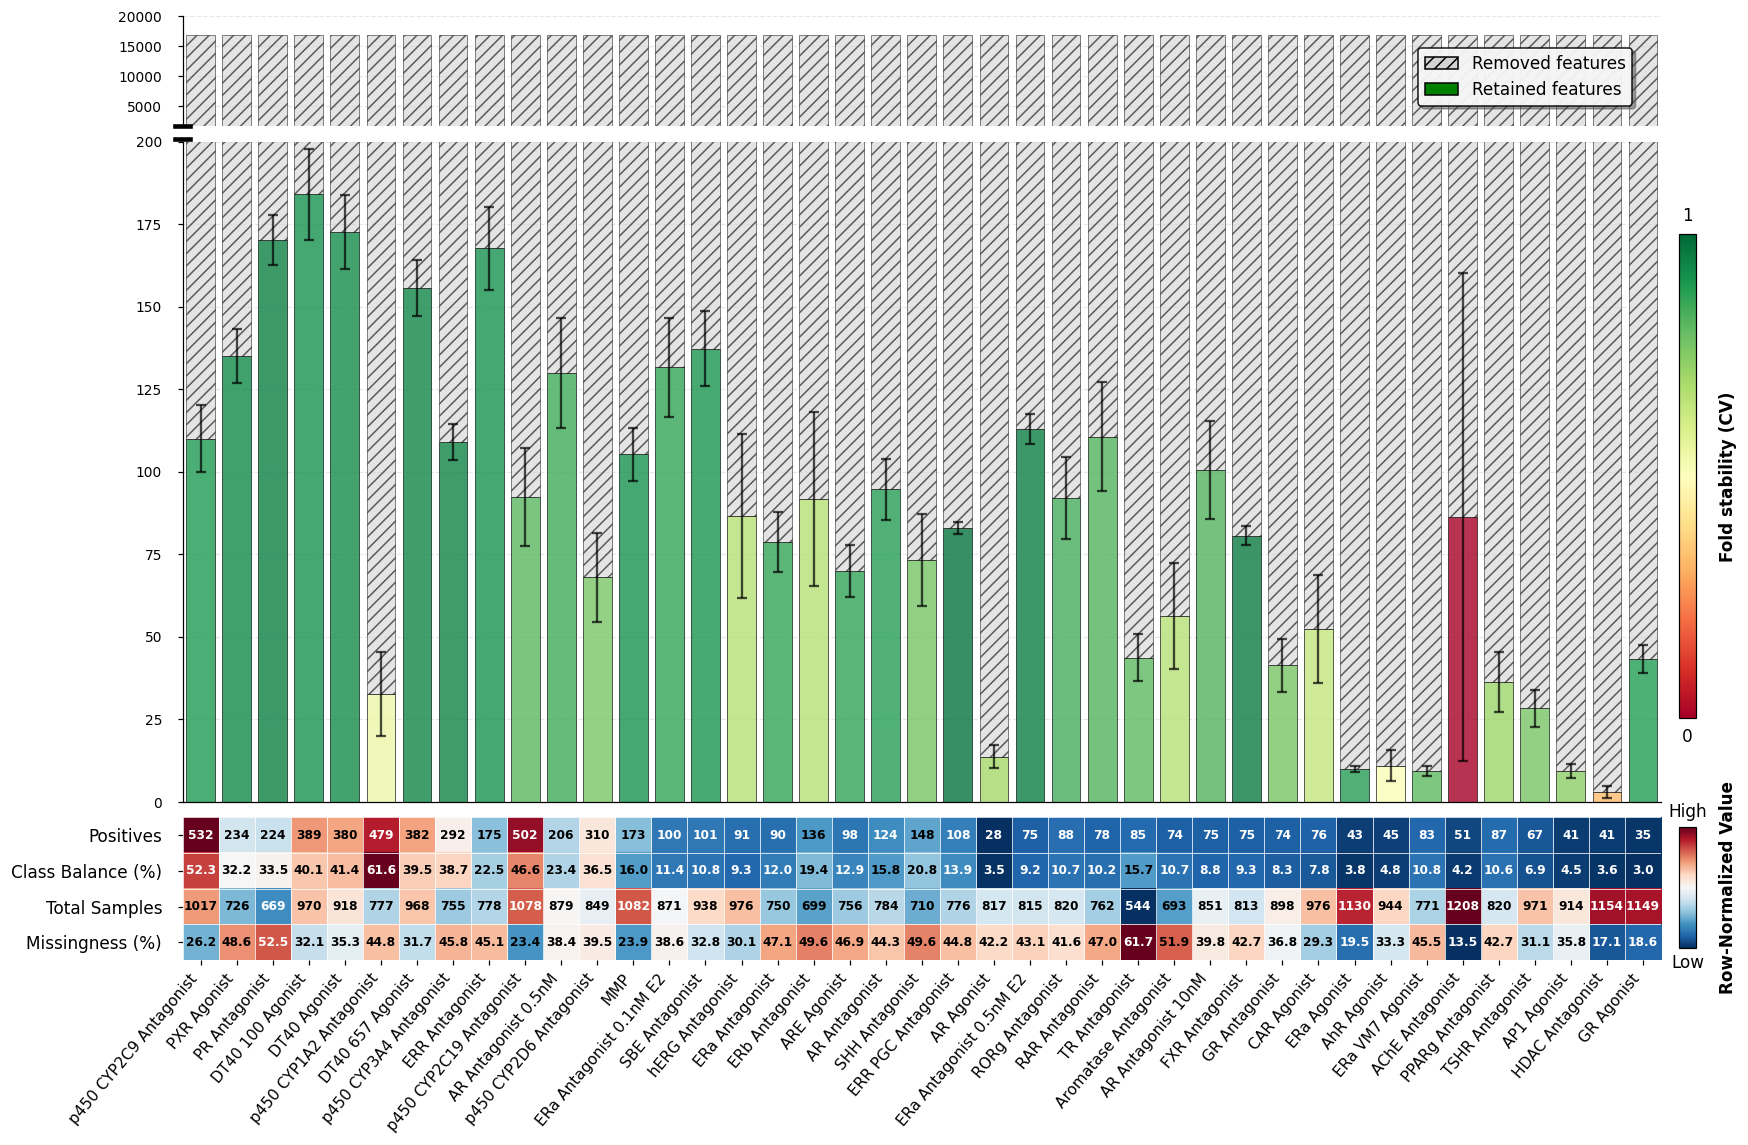

In [14]:
# FIGURE 1: Feature reduction and dataset characteristics across the 41 curated Tox21 assay endpoints. 
# Bar heights represent the number of transcriptomic features retained after Boruta selection relative 
# to the total feature space, and colors indicate cross-validation stability of retained features with 
# greener bars denoting more consistent feature selection across folds. Error bars represent the 
# standard deviation of feature counts across replicate Boruta runs. 
# The lower heatmap summarizes mean dataset characteristics for each assay across 3 folds, 
# including the number of positive samples, class balance, total sample size, and fraction of missing values. 
# Each metric was row-normalized to emphasize within-metric variation across assays. 
# Numerical annotations display the corresponding mean values.
# --------------------------------------------------------------------------------------- #


chemical_httr_assay_aggregated = pd.read_feather("../data/chemical_httr_assay_aggregated.feather")
assays   = [col for col in chemical_httr_assay_aggregated.columns if col.startswith("TOX21_")]
relevant = chemical_httr_assay_aggregated[assays + ['outcome_id']].drop_duplicates()

assay_missing_summary = (relevant[assays].isna().mean() * 100).rename_axis("assay_id").reset_index(name="missing_fraction")

def normalize_names(name):
    return (name.replace("0.1", "0_1")
                .replace("0.5", "0_5")
                .replace("1.0", "1_0"))

assay_missing_summary["assay_id_norm"] = assay_missing_summary["assay_id"].map(normalize_names)
performance_summary["assay_name_norm"] = performance_summary["assay_component_endpoint_name"].map(normalize_names)

def create_feature_reduction_waterfall(out_base_path="../output", heatmap_cmap='RdBu_r'):
    out_base = Path(out_base_path)
    rows = []
    for d in (p for p in out_base.iterdir() if p.is_dir()):
        summary_fp = d / "run_summary.json"
        details_fp = d / "fold_details.csv"
        if not (summary_fp.exists() and details_fp.exists()):
            continue

        with open(summary_fp, "r") as f:
            initial = json.load(f).get("n_httr_features", 0)

        details_df = pd.read_csv(details_fp)
        
        fold_counts = []
        for idx, row in details_df.iterrows():
            if 'selected_httr_features' in row and pd.notna(row['selected_httr_features']):
                try:
                    features = json.loads(row['selected_httr_features'])
                    fold_counts.append(len(features))
                except (json.JSONDecodeError, TypeError):
                    continue
        
        if not fold_counts:
            continue
            
        fold_counts = pd.Series(fold_counts)
        mean, std = fold_counts.mean(), fold_counts.std()
        cv = (std / mean) if mean else 0

        rows.append({
            "endpoint": d.name,
            "initial_features": initial,
            "selected_features_mean": mean,
            "selected_features_std": std,
            "selected_features_min": fold_counts.min(),
            "selected_features_max": fold_counts.max(),
            "selected_features_cv": cv,
            "reduction_count_mean": initial - mean,
            "reduction_percentage_mean": (initial - mean) / initial * 100 if initial else 0,
            "fold_counts": fold_counts.tolist(),
        })

    if not rows:
        print("No feature reduction data found!")
        return

    df = pd.DataFrame(rows)
    df["display_name"] = df["endpoint"].map(names_map)
    perf_order = {f"TOX21_{idx.replace(' ', '_')}": i for i, idx in enumerate(performance_summary.index)}
    df["order"] = df["endpoint"].map(perf_order)
    df = df.sort_values("order").reset_index(drop=True)

    x = np.arange(len(df))
    cv_max = max(df["selected_features_cv"].max(), 1e-12)
    norm = Normalize(vmin=0, vmax=cv_max)
    cmap = plt.cm.RdYlGn
    colors = cmap(1 - df["selected_features_cv"] / cv_max)

    def plot_bars(ax):
        ax.bar(x, df["selected_features_mean"], color=colors, alpha=0.8, edgecolor="black", linewidth=0.5, width=0.8)
        ax.errorbar(x, df["selected_features_mean"], yerr=df["selected_features_std"],
                    fmt="none", ecolor="black", capsize=3, capthick=1.5, alpha=0.7)
        ax.bar(x, df["reduction_count_mean"], bottom=df["selected_features_mean"],
               color="lightgray", alpha=0.6, edgecolor="black", linewidth=0.5, hatch="///", width=0.8)
        ax.grid(True, axis="y", linestyle="--", alpha=0.3)
        ax.set_axisbelow(True)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    missing_map_global = dict(zip(assay_missing_summary["assay_id_norm"], assay_missing_summary["missing_fraction"]))
    
    heatmap_vals = []
    for endpoint in df["endpoint"]:
        search_key = endpoint.replace("TOX21_", "").replace("_", " ")
        if search_key in performance_summary.index:
            row = performance_summary.loc[search_key]
            assay_norm_name = row.get('assay_name_norm')
            missing_val = missing_map_global.get(assay_norm_name, np.nan) if assay_norm_name else np.nan
            
            heatmap_vals.append({
                'Positives': row['test_pos_mean'],
                'Class Balance (%)': row['pos_fraction'] * 100,
                'Total Samples': row['total_samples'],
                'Missingness (%)': missing_val
            })
        else:
            heatmap_vals.append({'Positives': np.nan, 'Class Balance (%)': np.nan, 
                                'Total Samples': np.nan, 'Missingness (%)': np.nan})
    
    heatmap_data_df = pd.DataFrame(heatmap_vals).T
    
    def row_minmax(s):
        rng = s.max() - s.min()
        return (s - s.min()) / rng if rng != 0 else pd.Series(0.5, index=s.index)
    
    norm_heatmap = heatmap_data_df.apply(row_minmax, axis=1)
    
    annot_heatmap = pd.DataFrame(index=heatmap_data_df.index, columns=heatmap_data_df.columns)
    for row in ['Positives', 'Total Samples']:
        annot_heatmap.loc[row] = heatmap_data_df.loc[row].round(0).map(
            lambda v: f"{int(v)}" if pd.notna(v) and v != 0 else ("0" if v == 0 else "N/A"))
    for row in ['Class Balance (%)', 'Missingness (%)']:
        annot_heatmap.loc[row] = heatmap_data_df.loc[row].map(lambda v: f"{v:.1f}" if pd.notna(v) else "N/A")
    
    fig = plt.figure(figsize=(16, 11))
    gs = fig.add_gridspec(3, 1, height_ratios=[1, 6, 1.3], hspace=0.05, left=0.08, right=0.92, bottom=0.20)
    
    ax_top = fig.add_subplot(gs[0])
    ax_bot = fig.add_subplot(gs[1], sharex=ax_top)
    ax_heat = fig.add_subplot(gs[2], sharex=ax_top)
    
    for ax in (ax_top, ax_bot):
        plot_bars(ax)
    ax_top.set_ylim(1600, 20000)
    ax_bot.set_ylim(0, 200)

    d = .005
    kwargs = dict(transform=ax_top.transAxes, color='k', clip_on=False, linewidth=3)
    ax_top.plot((-d, +d), (+d, +d), **kwargs)
    kwargs.update(transform=ax_bot.transAxes)
    ax_bot.plot((-d, +d), (0.999+d, 0.999+d), **kwargs)

    ax_bot.set_xticks(x)
    ax_bot.set_xticklabels([])
    ax_top.spines["bottom"].set_visible(False)
    ax_top.tick_params(bottom=False)
    
    cmap_heat = mpl.colormaps.get_cmap(heatmap_cmap)
    im = ax_heat.imshow(norm_heatmap.values, aspect='auto', cmap=heatmap_cmap, 
                        vmin=0, vmax=1, interpolation='nearest')
    
    for spine in ax_heat.spines.values():
        spine.set_visible(False)
    
    for i in range(norm_heatmap.shape[0]):
        for j in range(norm_heatmap.shape[1]):
            text = annot_heatmap.iloc[i, j]
            normalized_value = norm_heatmap.iloc[i, j]
            rgba = cmap_heat(normalized_value)
            luminance = 0.299 * rgba[0] + 0.587 * rgba[1] + 0.114 * rgba[2]
            text_color = "white" if luminance < 0.5 else "black"
            ax_heat.text(j, i, text, ha="center", va="center", 
                        color=text_color, fontsize=8, weight='bold')
    
    ax_heat.set_yticks(range(len(norm_heatmap.index)))
    ax_heat.set_yticklabels(norm_heatmap.index, rotation=0, fontsize=11)
    ax_heat.set_xticks(range(len(norm_heatmap.columns)))
    ax_heat.set_xticklabels(df["display_name"], rotation=45, ha="right", fontsize=10)
    
    for i in range(len(norm_heatmap.columns) + 1):
        ax_heat.axvline(i - 0.5, color='white', linewidth=0.5)
    for i in range(len(norm_heatmap.index) + 1):
        ax_heat.axhline(i - 0.5, color='white', linewidth=0.5)
    
    ax_heat.set_xlim(-0.5, len(norm_heatmap.columns) - 0.5)
    ax_heat.set_ylim(len(norm_heatmap.index) - 0.5, -0.5)
    ax_heat.set_ylabel('')
    ax_heat.set_xlabel('')
    
    ax_top.set_xticks([])
    ax_top.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)
    ax_bot.set_xticks([])
    ax_bot.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)

    for ax in (ax_top, ax_bot, ax_heat):
        ax.tick_params(axis="y", which="both", pad=10)

    legend_elements = [
        Patch(facecolor="lightgray", edgecolor="black", hatch="///", label="Removed features"),
        Patch(facecolor="green", edgecolor="black", label="Retained features")
    ]

    ax_top.legend(handles=legend_elements, loc="upper left", bbox_to_anchor=(0.83, 0.79), 
                  fontsize=11, frameon=True, fancybox=True, shadow=True, framealpha=0.9,
                  edgecolor='black', facecolor='white')

    sm = ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar_ax = fig.add_axes([0.93, 0.4, 0.01, 0.4])
    cbar = fig.colorbar(sm, cax=cbar_ax)
    cbar.set_label("Fold stability (CV)", fontsize=11, labelpad=15, fontweight='bold')
    cbar.set_ticks([])
    cbar.ax.text(0.5, 1.02, '1', ha='center', va='bottom', fontsize=11, transform=cbar.ax.transAxes)
    cbar.ax.text(0.5, -0.02, '0', ha='center', va='top', fontsize=11, transform=cbar.ax.transAxes)
    
    cbar_heat_ax = fig.add_axes([0.93, 0.21, 0.01, 0.10])
    cbar_heat = fig.colorbar(im, cax=cbar_heat_ax)
    cbar_heat.set_label("Row-Normalized Value", fontsize=11, labelpad=15, fontweight='bold')
    cbar_heat.set_ticks([])
    cbar_heat.ax.text(0.5, 1.05, 'High', ha='center', va='bottom', fontsize=11, transform=cbar_heat.ax.transAxes)
    cbar_heat.ax.text(0.5, -0.05, 'Low', ha='center', va='top', fontsize=11, transform=cbar_heat.ax.transAxes)

    fig.subplots_adjust(left=0.08, right=0.92, bottom=0.17, top=0.98)
    
    ax_heat.set_xticks(range(len(df)))
    ax_heat.set_xticklabels(df["display_name"], rotation=50, ha="right", fontsize=10)
    ax_heat.tick_params(axis='x', labelbottom=True, bottom=True)
    
    #plt.savefig(out_base / "figure_01_feature_reduction_waterfall.svg", bbox_inches="tight")
    plt.savefig(out_base / "figure_01_feature_reduction_waterfall.png", bbox_inches="tight", dpi=300)
    plt.show()
    return df


reduction_summary = create_feature_reduction_waterfall("../output", heatmap_cmap='RdBu_r')

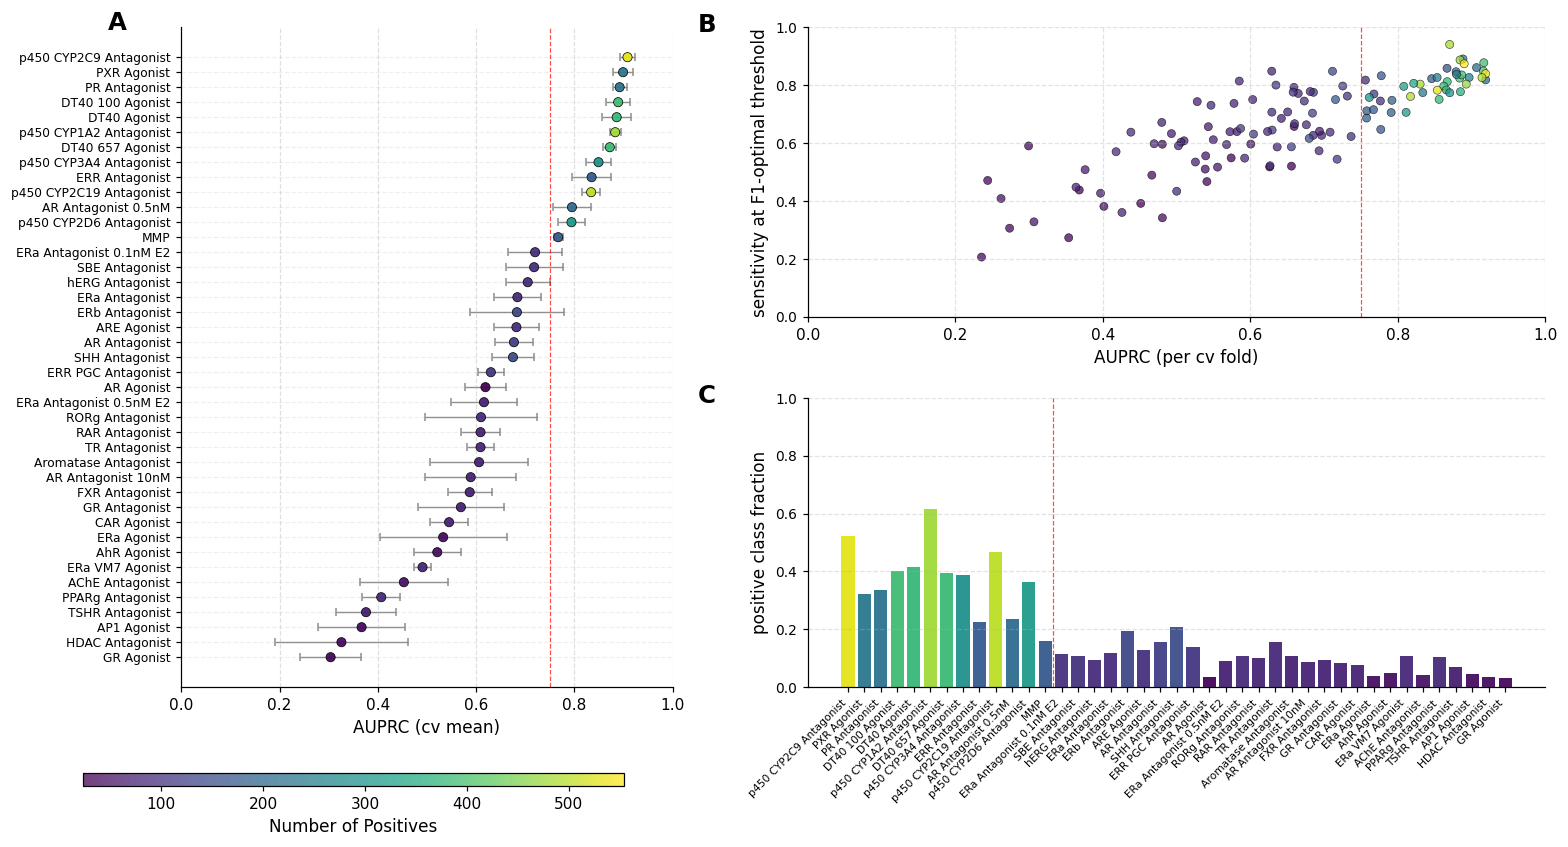

Out of 41 assays, 13 are considered predictable (mean PR AUC > 0.75):
- TOX21_AR_LUC_MDAKB2_Antagonist_0_5nM_R1881
- TOX21_DT40_100_LUC
- TOX21_DT40_657_LUC
- TOX21_DT40_LUC
- TOX21_ERR_LUC_Antagonist
- TOX21_MMP_ratio
- TOX21_PR_BLA_Antagonist_ratio
- TOX21_PXR_LUC_Agonist
- TOX21_p450_CYP1A2_Antagonist
- TOX21_p450_CYP2C19_Antagonist
- TOX21_p450_CYP2C9_Antagonist
- TOX21_p450_CYP2D6_Antagonist
- TOX21_p450_CYP3A4_Antagonist

These assays will be retained for further analysis.


In [15]:
# FIGURE 2: Cross-validated model performance, sensitivity, and class balance across the 41 curated Tox21 assays. 
# (A) Each point shows the mean area under the precision–recall curve (AUPRC) for individual assays, 
# with horizontal error bars indicating the standard deviation across cross-validation folds. 
# Point colors reflect the mean number of positive samples in the test sets, illustrating variation in class balance across assays. 
# The vertical dashed red line (AUPRC = 0.75) denotes the empirical performance threshold used to identify well-performing models for downstream analyses. 
# (B) Relationship between fold-level AUPRC and sensitivity at the F₁-optimal decision threshold. 
# Each point represents a single cross-validation fold, colored by the number of positive samples in that fold. 
# The vertical dashed red line marks the same AUPRC = 0.75 reference threshold as in panel A, 
# enabling direct comparison of fold-level and assay-level performance. 
# (C) Fraction of positive samples per assay, colored according to the shared “number of positives” color scale. 
# The vertical dashed red line corresponds to the same AUPRC = 0.75 reference threshold, facilitating visual alignment across panels.
# --------------------------------------------------------------------------------------- #

mpl.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 300, "font.size": 11,
    "axes.titlesize": 11, "axes.labelsize": 11, "axes.linewidth": 0.8,
    "xtick.labelsize": 10, "ytick.labelsize": 9
})

fig = plt.figure(figsize=(16,10))
gs = fig.add_gridspec(2, 2, width_ratios=[1, 1.5], height_ratios=[1, 1], hspace=0.28, wspace=0.22)

ax1 = fig.add_subplot(gs[:, 0])  
ax2 = fig.add_subplot(gs[0, 1])  
ax3 = fig.add_subplot(gs[1, 1])  

pos_min = min(all_fold_metrics["test_pos"].min(), performance_summary["test_pos_mean"].min())
pos_max = max(all_fold_metrics["test_pos"].max(), performance_summary["test_pos_mean"].max())
norm_pos = mpl.colors.Normalize(vmin=pos_min, vmax=pos_max)
cmap = mpl.colormaps.get_cmap("viridis")

# Panel A: Assay-level PR-AUC
ax1.errorbar(performance_summary["pr_auc_mean"], performance_summary.index,
    xerr=performance_summary["pr_auc_std"], fmt="none", ecolor="0.5", elinewidth=0.9,
    capsize=2.5, alpha=0.9, zorder=1)
ax1.scatter(performance_summary["pr_auc_mean"], performance_summary.index,
    c=performance_summary["test_pos_mean"], s=36, alpha=0.95, linewidths=0.5,
    edgecolors="black", cmap=cmap, norm=norm_pos, zorder=2)
ax1.invert_yaxis()
ax1.set_xlim(0,1)
ax1.set_yticks(range(len(performance_summary)))
ax1.set_yticklabels(performance_summary['display_name'], fontsize=8)
ax1.set_xlabel("AUPRC (cv mean)")
ax1.grid(axis="x", linestyle="--", alpha=0.4)
ax1.grid(axis="y", linestyle="--", alpha=0.20)
ax1.text(-0.15, 1.025, 'A', transform=ax1.transAxes, fontsize=16, fontweight='bold', va='top')
ax1.axvline(x=0.75, color='red', linestyle='--', linewidth=0.8, alpha=0.7)

# Panel B: Fold-level AUPRC vs Sensitivity
sc2 = ax2.scatter(all_fold_metrics["pr_auc"], all_fold_metrics["recall_at_optimal"],
    c=all_fold_metrics["test_pos"], s=28, alpha=0.75, linewidths=0.4, edgecolors="black",
    cmap=cmap, norm=norm_pos)
ax2.set_xlabel("AUPRC (per cv fold)")
ax2.set_ylabel("sensitivity at F1-optimal threshold")
ax2.set_xlim(0,1)
ax2.set_ylim(0,1)
ax2.grid(True, linestyle="--", alpha=0.35)
ax2.text(-0.15, 1.05, 'B', transform=ax2.transAxes, fontsize=16, fontweight='bold', va='top')
ax2.axvline(x=0.75, color='red', linestyle='--', linewidth=0.8, alpha=0.7)

# Panel C: Class imbalance (positive fractions)
x_positions = range(len(performance_summary))
ax3.bar(x_positions, performance_summary['pos_fraction'],
        color=cmap(norm_pos(performance_summary['test_pos_mean'].values)),
        linewidth=0.3, alpha=0.95)
ax3.set_xticks(x_positions)
ax3.set_xticklabels(performance_summary['display_name'], rotation=45, ha="right", fontsize=7)
ax3.set_ylabel("positive class fraction")
ax3.set_ylim(0, 1)
ax3.grid(axis="y", linestyle="--", alpha=0.35)
ax3.text(-0.15, 1.05, 'C', transform=ax3.transAxes, fontsize=16, fontweight='bold', va='top')
ax3.axvline(x=12.5, color='red', linestyle='--', linewidth=0.8, alpha=0.7)

for ax in [ax1, ax2, ax3]:
    for spine in ("top","right"):
        ax.spines[spine].set_visible(False)

# Colorbar underneath ax1
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
cax = inset_axes(ax1, width="110%", height="2%", loc="lower center",
                 bbox_to_anchor=(-0.15, -0.15, 1, 1), bbox_transform=ax1.transAxes, borderpad=0)
cbar = fig.colorbar(sc2, cax=cax, orientation="horizontal")
cbar.set_label("Number of Positives")

fig.subplots_adjust(bottom=0.28)

# Save figure
fig.savefig("../output/figure_02_assay_performance_metrics_panel.png", bbox_inches="tight", dpi=600)
#fig.savefig("../output/figure_02_assay_performance_metrics_panel.svg", bbox_inches="tight")
plt.show()

# Assays with an average PR AUC > 0.75 are considered "predictable", and are retained for further analysis
all_assays = all_fold_metrics["assay"].unique()
assays = []
predictable_assays = all_fold_metrics.groupby("assay", observed=True).filter(lambda x: x["pr_auc"].mean() > 0.75)["assay"].unique()
print(f"Out of {len(all_assays)} assays, {len(predictable_assays)} are considered predictable (mean PR AUC > 0.75):")
for assay in predictable_assays:
    assays.append(assay)
    print(f"- {assay}")

print("\nThese assays will be retained for further analysis.")

In [16]:
# FIGURE 3: SHAP-based feature importance analysis for predictable assays.
# For each assay with AUPRC > 0.75, this analysis:
# 1. Ranks features by mean absolute SHAP value across all test samples
# 2. Generates violin plots showing SHAP value distributions for top 20 features
# The violin plots are colored by feature value magnitude (blue=low, red=high)
# and include a side panel showing mean absolute SHAP importance.
# --------------------------------------------------------------------------------------- #

OUT_BASE = Path("../output")

def rank_features_for_assay(assay_dir):
    """
    Rank features by mean absolute SHAP value for a given assay.
    Returns DataFrame with feature rankings and SHAP statistics.
    """
    oof_path = assay_dir / "shap" / "oof_shap.feather"
    if not oof_path.exists():
        return None

    oof = pd.read_feather(oof_path)
    shap_cols = [c for c in oof.columns if c.startswith("SHAP_")]
    if not shap_cols:
        return None

    mean_abs = oof[shap_cols].abs().mean()

    has_labels = "y_true" in oof.columns
    if has_labels:
        pos_mask = (oof["y_true"] == 1)
        neg_mask = (oof["y_true"] == 0)
        mean_pos = oof.loc[pos_mask, shap_cols].mean()
        mean_neg = oof.loc[neg_mask, shap_cols].mean()
        
        shap_corr = {}
        y = oof["y_true"].astype(float).values
        for c in shap_cols:
            x = oof[c].values
            if np.std(x) == 0:
                shap_corr[c] = np.nan
            else:
                shap_corr[c] = np.corrcoef(x, y)[0, 1]
        shap_corr = pd.Series(shap_corr)
    else:
        mean_pos  = pd.Series(index=shap_cols, dtype=float)
        mean_neg  = pd.Series(index=shap_cols, dtype=float)
        shap_corr = pd.Series(index=shap_cols, dtype=float)

    features = [c.replace("SHAP_", "") for c in shap_cols]

    df = pd.DataFrame({
        "feature": features,
        "mean_abs_shap": mean_abs.values,
        "mean_shap_pos": mean_pos.reindex(shap_cols).values if has_labels else np.nan,
        "mean_shap_neg": mean_neg.reindex(shap_cols).values if has_labels else np.nan,
        "shap_corr_with_label": shap_corr.reindex(shap_cols).values if has_labels else np.nan,
    })
    
    df = df.sort_values("mean_abs_shap", ascending=False).reset_index(drop=True)
    df["rank_by_abs_shap"] = np.arange(1, len(df) + 1)

    out_path = assay_dir / "feature_ranking.csv"
    df.to_csv(out_path, index=False)
    return df

# Process all predictable assays
all_rows = []
predictable_assays_set = set(predictable_assays)

for assay_dir in sorted([p for p in OUT_BASE.iterdir() if p.is_dir()]):
    if assay_dir.name in predictable_assays_set:
        df_rank = rank_features_for_assay(assay_dir)
        if df_rank is None:
            continue
        df_rank["assay"] = assay_dir.name
        all_rows.append(df_rank)


# SHAP violin plot generation
TOP_K = 20
CUSTOM_CMAP = LinearSegmentedColormap.from_list(
    "colors",
    [(0.00, "#2c84fb"), (0.25, "#2c84fb"), (0.75, "#ff1651"), (1.00, "#ff1651")]
)

def load_topk(feather_path, top_k):
    oof = pd.read_feather(feather_path)
    shap_cols = [c for c in oof.columns if c.startswith("SHAP_")]

    if not shap_cols:
        return [], None, None, None

    valid_shap_cols = [c for c in shap_cols if np.any(np.isfinite(oof[c].values))]

    mean_abs = oof[valid_shap_cols].abs().mean().sort_values(ascending=False)
    top_cols = mean_abs.index[:top_k]
    shap_mat = oof[top_cols].to_numpy()

    feature_names = [c.replace("SHAP_", "") for c in top_cols]
    have_all_values = all(b in oof.columns for b in feature_names)
    X_vals = oof[feature_names].to_numpy() if have_all_values else None

    return feature_names, shap_mat, X_vals, mean_abs.loc[top_cols]


def scale(x):
    x = x.astype(float)
    m = np.isfinite(x)
    out = np.full_like(x, np.nan, float)
    if not np.any(m):
        return out
    q1, q99 = np.nanpercentile(x[m], [1, 99])
    if q99 <= q1:
        out[m] = 0.5
        return out
    xc = np.clip(x, q1, q99)
    out[m] = (xc[m] - q1) / (q99 - q1)
    return out


def violin_plot(ax, shap_mat, feature_names, feature_values=None, bins=200):
    n_samples, n_features = shap_mat.shape
    y_positions = np.arange(n_features)[::-1]
    ax.axvline(0.0, linewidth=1, color="black", alpha=0.25, zorder=1)

    finite_vals = shap_mat[np.isfinite(shap_mat)]
    if finite_vals.size > 0:
        abs_max = np.max(np.abs(finite_vals))
        ax.set_xlim(-abs_max, abs_max)

    valid_positions, valid_names, valid_idx = [], [], []
    for j, pos in enumerate(y_positions):
        s = shap_mat[:, j]
        s = s[np.isfinite(s)]
        if s.size > 0:
            valid_idx.append(j)
            valid_positions.append(pos)
            valid_names.append(feature_names[j])

    if valid_positions:
        ax.set_ylim(min(valid_positions) - 0.6, max(valid_positions) + 0.6)

    ax.grid(True, axis='x', linestyle=':', linewidth=0.5, alpha=0.6)
    ax.grid(True, axis='y', linestyle=':', linewidth=0.3, alpha=0.6)

    for j, pos in zip(valid_idx, valid_positions):
        svals = shap_mat[:, j]
        m = np.isfinite(svals)
        s = svals[m]
        if s.size == 0:
            continue

        f = None
        if feature_values is not None:
            fvals = feature_values[:, j]
            f = scale(fvals)[m]

        parts = ax.violinplot([s], positions=[pos], vert=False, widths=0.6,
                              showmeans=False, showmedians=False, showextrema=False)
        body = parts["bodies"][0]
        verts = body.get_paths()[0].vertices
        body.remove()

        patch = PathPatch(MplPath(verts), facecolor="none", edgecolor="black", linewidth=0.3, alpha=0.9, zorder=3)
        ax.add_patch(patch)

        x = verts[:, 0]
        y = verts[:, 1]
        xmin, xmax = np.min(x), np.max(x)
        ymin_v, ymax_v = np.min(y), np.max(y)
        if not np.isfinite(xmin) or not np.isfinite(xmax) or xmax == xmin:
            continue

        edges = np.linspace(xmin, xmax, bins + 1)
        idx = np.digitize(s, edges) - 1
        idx = np.clip(idx, 0, bins - 1)
        col = np.full(bins, 0.5, dtype=float)
        if f is not None and f.size == s.size:
            for b in range(bins):
                mb = idx == b
                if np.any(mb):
                    col[b] = np.nanmean(f[mb])

        img = col[np.newaxis, :]
        im = ax.imshow(
            img,
            extent=[xmin, xmax, ymin_v, ymax_v],
            cmap=CUSTOM_CMAP,
            vmin=0.0,
            vmax=1.0,
            aspect="auto",
            origin="lower",
            interpolation="bilinear",
            zorder=2
        )
        im.set_clip_path(patch)

    ax.set_yticks(valid_positions)
    ax.set_yticklabels(valid_names, fontsize=10)
    ax.set_xlabel("SHAP value", fontsize=11)
    for spine in ("top", "right"):
        ax.spines[spine].set_visible(False)


def plot_violin_plus_importance(assay_name, feature_names, shap_mat, feature_values, save=False):
    valid_feat_mask = ~np.all(~np.isfinite(shap_mat), axis=0)
    shap_mat_f = shap_mat[:, valid_feat_mask]
    feature_names_f = [f for f, keep in zip(feature_names, valid_feat_mask) if keep]
    feature_values_f = feature_values[:, valid_feat_mask] if feature_values is not None else None
    if shap_mat_f.size == 0:
        print("No valid SHAP values to plot.")
        return

    mean_abs_now = np.nanmean(np.abs(shap_mat_f), axis=0)
    order = np.argsort(-mean_abs_now)
    shap_mat_ord = shap_mat_f[:, order]
    feature_names_ord = [feature_names_f[i] for i in order]
    importance_ord = mean_abs_now[order]
    feature_values_ord = feature_values_f[:, order] if feature_values_f is not None else None

    fig, (ax_left, ax_right) = plt.subplots(
        1, 2, figsize=(14, 9), dpi=160,
        gridspec_kw={"width_ratios": [4, 1], "wspace": 0.05}
    )

    violin_plot(ax_left, shap_mat_ord, feature_names_ord, feature_values=feature_values_ord, bins=3)

    if feature_values_ord is not None:
        from matplotlib.cm import ScalarMappable
        from matplotlib.colors import Normalize

        norm = Normalize(vmin=0.0, vmax=1.0)
        sm = ScalarMappable(norm=norm, cmap=CUSTOM_CMAP)
        sm.set_array([])

        cbar = fig.colorbar(sm, ax=ax_left, fraction=0.046, pad=0.04)
        cbar.set_ticks([])
        cbar.ax.set_yticklabels([])
        cbar.outline.set_visible(True)
        cbar.outline.set_linewidth(10)
        cbar.outline.set_edgecolor("white")
        cbar.ax.text(0.5, 1.0, "High", ha="center", va="bottom", fontsize=9, transform=cbar.ax.transAxes)
        cbar.ax.text(0.5, 0.0, "Low",  ha="center", va="top",    fontsize=9, transform=cbar.ax.transAxes)
        cbar.set_label("Feature value", labelpad=-37.5, fontsize=10)

    ax_left.set_title(f"Top {TOP_K} SHAP Plot — {assay_name}", fontsize=14, fontweight='bold', loc="center", pad=10)

    y_pos = np.arange(len(feature_names_ord))[::-1]

    bars = ax_right.barh(y_pos, importance_ord, alpha=0.9, height=0.6, edgecolor="none", color="#00B894")

    ax_right.grid(True, axis='x', linestyle=':', linewidth=0.5, alpha=0.6)
    ax_right.grid(True, axis='y', linestyle=':', linewidth=0.3, alpha=0.6)
    ax_right.set_yticks(y_pos)
    ax_right.set_yticklabels([])
    ax_right.set_xlabel("mean(|SHAP|)", fontsize=10)
    ax_right.set_title("Feature Importance", fontsize=14, pad=10, fontweight="bold", loc="center")
    ax_right.set_ylim(ax_left.get_ylim())
    ax_right.spines["top"].set_visible(False)
    ax_right.spines["right"].set_visible(False)

    max_val = np.nanmax(importance_ord)
    pad = (max_val * 0.02) if np.isfinite(max_val) and max_val > 0 else 0.01
    for bar, val in zip(bars, importance_ord):
        ax_right.text(val + pad, bar.get_y() + bar.get_height()/2,
                      f"{val:.3f}", va="center", ha="left", fontsize=8, alpha=0.85)

    if save: 
        out_path = assay_dir / "shap" / f"shap_{assay_dir.name}.svg"
        #plt.savefig(out_path, bbox_inches='tight', format="svg")
        plt.savefig(out_path.with_suffix('.png'), bbox_inches='tight', format="png", dpi=300)
        plt.close(fig)

        #display(SVG(filename=out_path)) # to view here in jupyter
    else: 
        plt.show()


assay_dirs = sorted([p for p in OUT_BASE.iterdir() if p.is_dir() and p.name in predictable_assays])
if assay_dirs:
    for assay_dir in assay_dirs:
        shap_file = assay_dir / "shap" / "oof_shap.feather"
        if not shap_file.exists():
            continue

        feature_names, shap_mat, X_vals, _ = load_topk(shap_file, TOP_K)
        if shap_mat is None or shap_mat.size == 0:
            continue

        assay_name_pretty = assay_dir.name.replace("_", " ").replace("TOX21", "")
        plot_violin_plus_importance(assay_name_pretty, feature_names, shap_mat, X_vals, save=True)

print("Done generating violin plots.")

Done generating violin plots.
